# Numerical Mixing Analyses for Figures 9-10

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from glob import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from itertools import cycle
from itertools import cycle
import xroms
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

from bichan_utils import * # Read in pl33tn low-pass filter function

In [ ]:
# --------------------------------------------------
# Helpers
# --------------------------------------------------
def res_to_meters(res):
    """'10km' → 10000, '500m' → 500"""
    if res.endswith("km"):
        return int(res[:-2]) * 1000
    elif res.endswith("m"):
        return int(res[:-1])
    else:
        raise ValueError(f"Unknown resolution: {res}")

def meters_to_label(m):
    """10000 → '10km', 500 → '500m'"""
    return f"{m//1000}km" if m >= 1000 else f"{m}m"

pathsd = [
    "MPAS-O/mixing_outputs/mixing_10000m_*.nc",
    "MPAS-O/mixing_outputs/mixing_5000*.nc",
    "MPAS-O/mixing_outputs/mixing_2000*.nc",
    "MPAS-O/mixing_outputs/mixing_1000m*.nc",
    "MPAS-O/mixing_outputs/mixing_500m*.nc",
    "MPAS-O/mixing_outputs/mixing_200m*.nc",
    "MPAS-O/mixing_outputs/mixing_100m_*.nc",
]


mpas_map = {}
for p in pathsd:
    files = sorted(glob(p))
    if not files:
        continue  # skip if no files found
    for f in files:
        fname = os.path.basename(f)
        m_search = re.search(r"mixing_(\d+)(m)?", fname)
        if m_search and m_search.group(2) == "m":
            res_m = int(m_search.group(1))
        elif m_search:
            res_m = int(m_search.group(1))
        else:
            res_m = 100
        if res_m not in mpas_map:
            mpas_map[res_m] = []
        mpas_map[res_m].append(f)

# --------------------------------------------------
# ROMS mixing outputs (chunked)
# --------------------------------------------------
paths_roms = [
    "ROMS/mixing_calcs/10km/mixing_calcs/mixing_*.nc",
    "ROMS/mixing_calcs/5km/mixing_calcs/mixing_*.nc",
    "ROMS/mixing_calcs/2km/mixing_calcs/mixing_*.nc",
    "ROMS/mixing_calcs/1km/mixing_calcs/mixing_*.nc",
    "ROMS/mixing_calcs/500m/mixing_calcs/mixing_*.nc",
    "ROMS/mixing_calcs/200m/mixing_calcs/mixing_*.nc",
    "ROMS/mixing_calcs/100m/mixing_calcs/mixing_*.nc",
]

roms_map = {}
for p in paths_roms:
    files = sorted(glob(p))
    if not files:
        continue
    # --- Determine resolution ---
    if "100m" in p or "100m_mixing" in p:
        res_m = 100
    else:
        res_str = re.search(r"/(\d+km|\d+m)/", p)
        if res_str:
            res_m = res_to_meters(res_str.group(1))
        else:
            continue  # skip if cannot infer resolution
    roms_map[res_m] = files


# --------------------------------------------------
# Matched resolutions (MPAS-O + ROMS) but include MPAS-only
# --------------------------------------------------
all_resolutions_m = sorted(set(mpas_map.keys()) | set(roms_map.keys()))
resolutions = [meters_to_label(m) for m in all_resolutions_m]

print("Matched MPAS-O / ROMS resolutions (MPAS-only included if ROMS missing):")
for m in all_resolutions_m:
    mpas_count = len(mpas_map[m]) if m in mpas_map else 0
    roms_count = len(roms_map[m]) if m in roms_map else 0

    if mpas_count > 0 and roms_count > 0:
        status = "MPAS-O & ROMS"
    elif mpas_count > 0 and roms_count == 0:
        status = "MPAS-O only"
    else:
        status = "ROMS only"

    print(f"  {meters_to_label(m)} ({m} m) - {status}")
    if mpas_count:
        print(f"    MPAS-O files: {mpas_count}")
    if roms_count:
        print(f"    ROMS files:   {roms_count}")


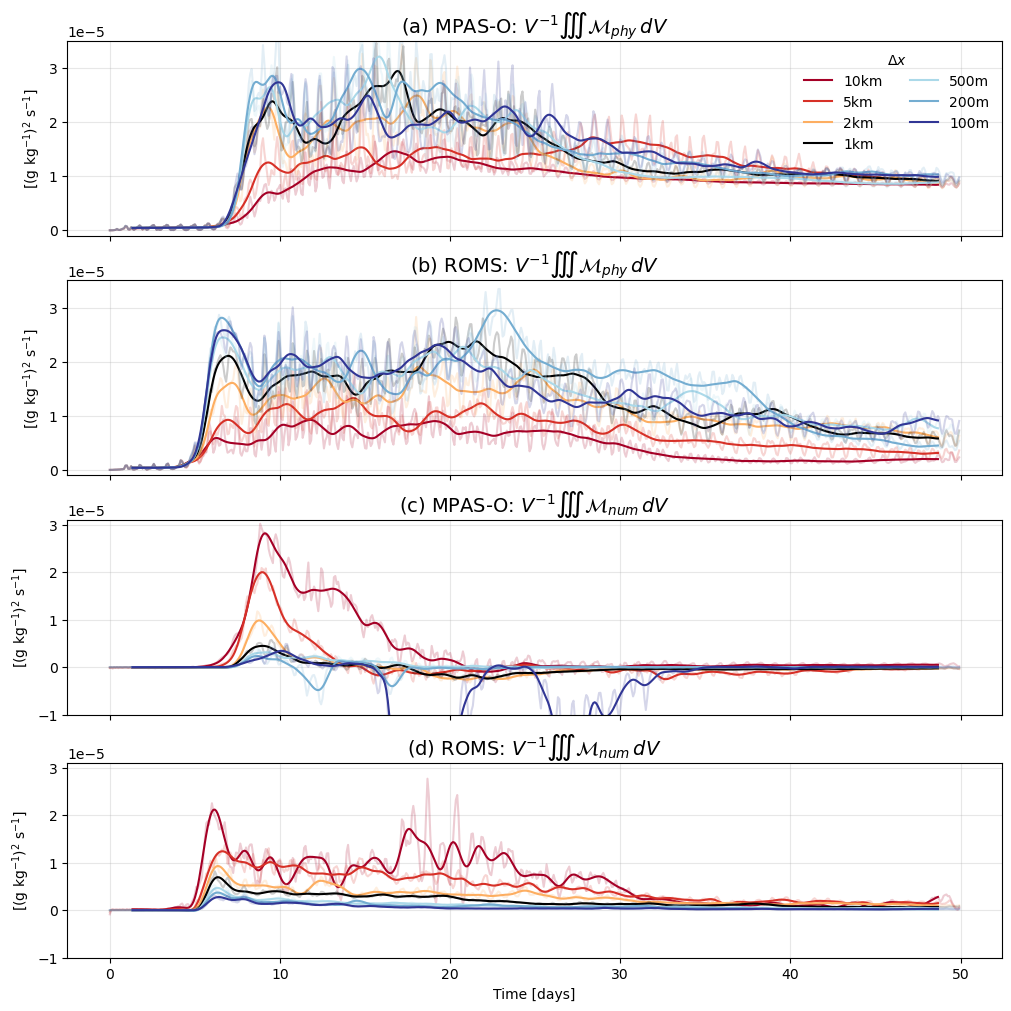

In [7]:
# -----------------------------
# Use the union of all resolutions (MPAS or ROMS)
# -----------------------------
all_res_m = sorted(set(mpas_map) | set(roms_map))
rainbow_cmap = np.asarray([
    [165, 0, 38],
    [215, 48, 39],
    [253, 174, 97],
    [0, 0, 0],
    [171, 217, 233],
    [116, 173, 209],
    [49, 54, 149]
]) / 255

# -----------------------------
# Figure setup: 4 rows
# -----------------------------
fig, axs = plt.subplots(
    4, 1, figsize=(10, 10), sharex=True, constrained_layout=True
)
ax_mpas_phy, ax_roms_phy, ax_mpas_num, ax_roms_num = axs

# -----------------------------
# Time array
# -----------------------------
ndays = 50
dt = 2/24  # 2-hour time step in days
tsteps = int(ndays / dt)
time = np.linspace(0, ndays - dt, tsteps)

# -----------------------------
# Loop over all resolutions (coarse -> fine)
# -----------------------------
for icolor, res_m in enumerate(all_res_m[::-1]):
    color = rainbow_cmap[icolor % len(rainbow_cmap), :]
    label = meters_to_label(res_m)

    # =============================
    # MPAS-O
    # =============================
    if res_m in mpas_map:
        dsm = xr.open_mfdataset(mpas_map[res_m], combine="by_coords").isel(Time=slice(0,600))
        Mphy_mpas = dsm.Mphy_salt.values[:tsteps]
        Mnum_mpas = dsm.Mnum_salt.values[:tsteps]

        Mphy_mpas_f = pl33tn(Mphy_mpas, dt=2.0, T=33.0, mode="same")
        Mnum_mpas_f = pl33tn(Mnum_mpas, dt=2.0, T=33.0, mode="same")

        # Physical
        ax_mpas_phy.plot(time, Mphy_mpas, color=color, alpha=0.2)
        ax_mpas_phy.plot(time, Mphy_mpas_f, color=color, label=label)

        # Numerical
        ax_mpas_num.plot(time, Mnum_mpas, color=color, alpha=0.2)
        ax_mpas_num.plot(time, Mnum_mpas_f, color=color)

    # =============================
    # ROMS
    # =============================
    if res_m in roms_map:
        dsr = xr.open_mfdataset(roms_map[res_m], combine="by_coords").isel(ocean_time=slice(0,600))
        Mphy_roms = dsr.Mphy.values[:tsteps]
        Mnum_roms = dsr.Mnum.values[:tsteps]

        Mphy_roms_f = pl33tn(Mphy_roms, dt=2.0, T=33.0, mode="same")
        Mnum_roms_f = pl33tn(Mnum_roms, dt=2.0, T=33.0, mode="same")

        # Physical
        ax_roms_phy.plot(time, Mphy_roms, color=color, alpha=0.2)
        ax_roms_phy.plot(time, Mphy_roms_f, color=color)

        # Numerical
        ax_roms_num.plot(time, Mnum_roms, color=color, alpha=0.2)
        ax_roms_num.plot(time, Mnum_roms_f, color=color)

# -----------------------------
# Formatting
# -----------------------------
ax_mpas_phy.set_title("(a) MPAS-O: $V^{-1} \iiint \mathcal{M}_{phy} \, dV$", fontsize=14)
ax_roms_phy.set_title("(b) ROMS: $V^{-1} \iiint \mathcal{M}_{phy} \, dV$", fontsize=14)
ax_mpas_num.set_title("(c) MPAS-O: $V^{-1} \iiint \mathcal{M}_{num} \, dV$", fontsize=14)
ax_roms_num.set_title("(d) ROMS: $V^{-1} \iiint \mathcal{M}_{num} \, dV$", fontsize=14)

# Y-axis ranges
ax_mpas_phy.set_ylim(-0.1e-5, 3.5e-5)
ax_roms_phy.set_ylim(-0.1e-5, 3.5e-5)
ax_mpas_num.set_ylim(-1e-5, 3.1e-5)
ax_roms_num.set_ylim(-1e-5, 3.1e-5)

# Labels
for ax in axs:
    ax.set_ylabel("[(g kg$^{-1}$)$^2$ s$^{-1}$]")
    ax.grid(True, alpha=0.3)
ax_roms_num.set_xlabel("Time [days]")

# Legend only on top subplot
ax_mpas_phy.legend(title="$\Delta x$", frameon=False, ncol=2)




Processing resolution: 10000 m (10 km)
  MPAS-O: ratio = 42.37%, num = 2.154e-03, phy = 5.083e-03, total = 7.236e-03
  ROMS:    ratio = 130.98%, num = 3.363e-03, phy = 2.567e-03, total = 5.930e-03

Processing resolution: 5000 m (5 km)
  MPAS-O: ratio = 16.41%, num = 1.070e-03, phy = 6.516e-03, total = 7.586e-03
  ROMS:    ratio = 64.46%, num = 2.541e-03, phy = 3.943e-03, total = 6.484e-03

Processing resolution: 2000 m (2 km)
  MPAS-O: ratio = 8.78%, num = 6.260e-04, phy = 7.129e-03, total = 7.755e-03
  ROMS:    ratio = 24.76%, num = 1.531e-03, phy = 6.181e-03, total = 7.712e-03

Processing resolution: 1000 m (1 km)
  MPAS-O: ratio = 6.12%, num = 4.735e-04, phy = 7.741e-03, total = 8.214e-03
  ROMS:    ratio = 14.20%, num = 1.041e-03, phy = 7.336e-03, total = 8.378e-03

Processing resolution: 500 m (500 m)
  MPAS-O: ratio = 3.11%, num = 2.429e-04, phy = 7.800e-03, total = 8.043e-03
  ROMS:    ratio = 7.44%, num = 5.726e-04, phy = 7.701e-03, total = 8.273e-03

Processing resolution: 20

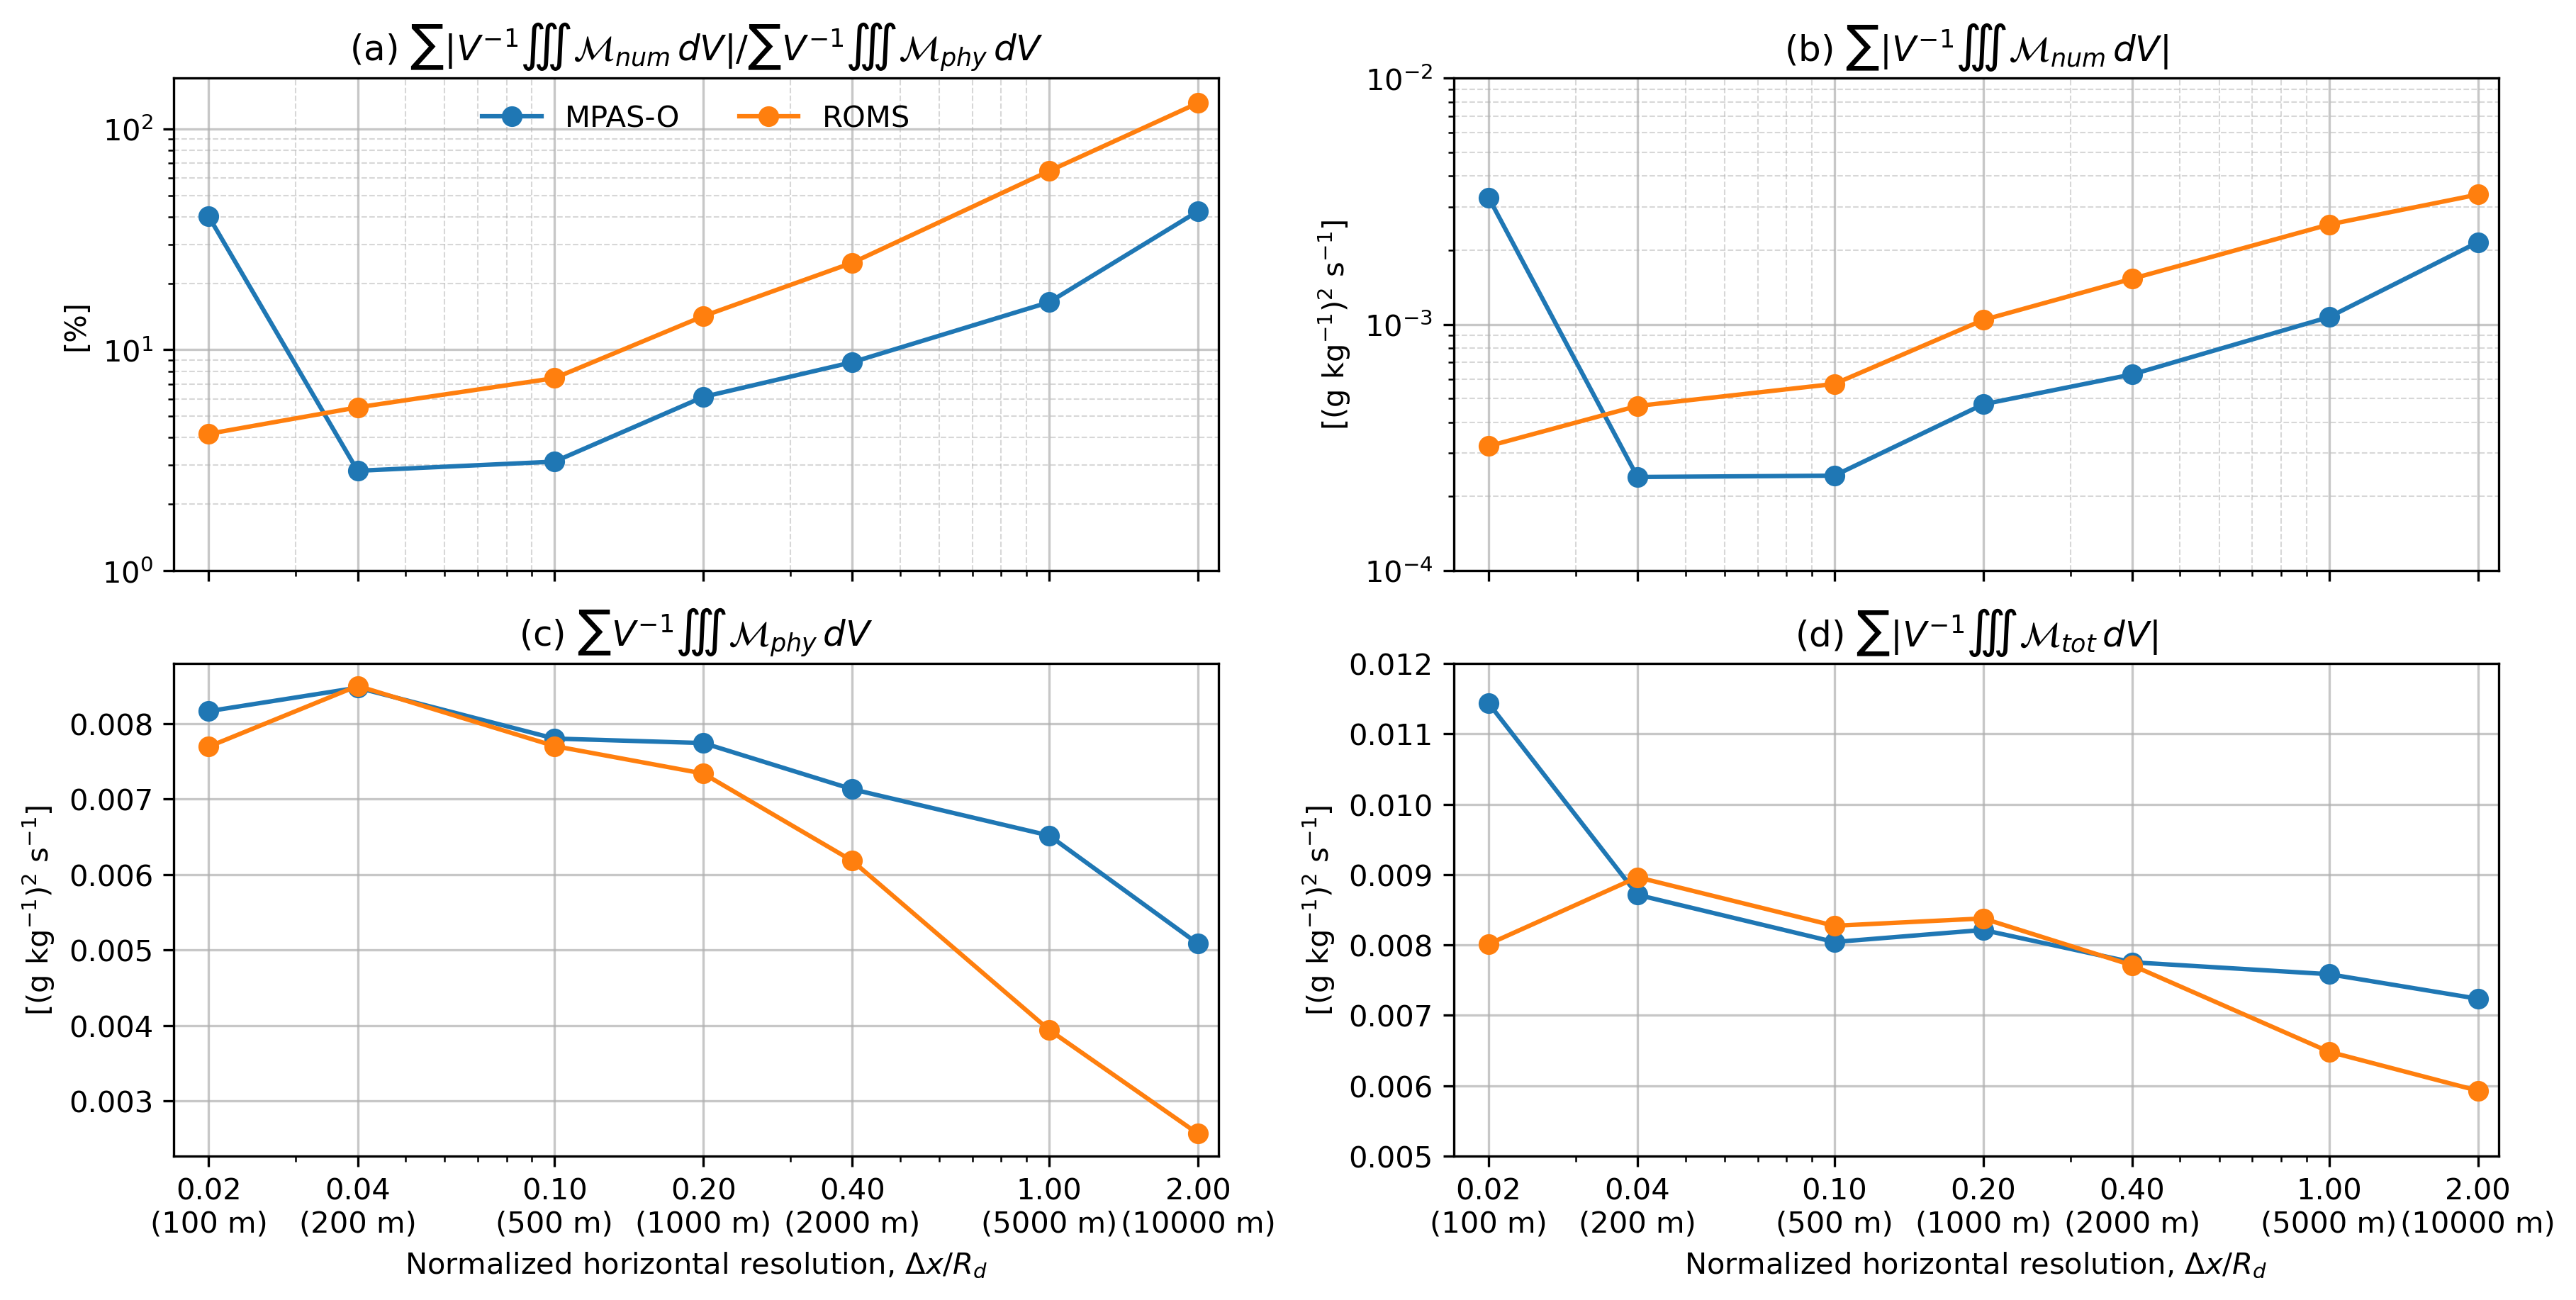

In [16]:
import numpy as np
import xarray as xr
from matplotlib.ticker import LogLocator
import matplotlib.pyplot as plt

# -----------------------------
# Marker and color setup
# -----------------------------
markers = ['o', 'o', 'o', 'o', 'o', 'o']
colors = {'MPAS': 'tab:blue', 'ROMS': 'tab:orange'}
linthresh = 1e-1

# -----------------------------
# Resolutions in meters
# -----------------------------
resolutions_m = [10000, 5000, 2000, 1000, 500, 200]
res_labels = ["10 km", "5 km", "2 km", "1 km", "500 m", "200 m"]

# -----------------------------
# Prepare figure with 2x2 subplots
# -----------------------------
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6),
                       constrained_layout=True, dpi=300)

# Flatten axes for easier indexing
ax = ax.flatten()

# -----------------------------
# Prepare lists to store data
# -----------------------------
x_vals = []
mpas_ratio = []
roms_ratio = []
mpas_num = []
roms_num = []
mpas_phy = []
roms_phy = []
mpas_tot = []
roms_tot = []

# -----------------------------
# Resolutions in meters (added 100 m)
# -----------------------------
resolutions_m = [10000, 5000, 2000, 1000, 500, 200, 100]
res_labels = ["10 km", "5 km", "2 km", "1 km", "500 m", "200 m", "100 m"]

# -----------------------------
# Loop over resolutions with print statements
# -----------------------------
for idx, res_m in enumerate(all_res_m[::-1]):
    # Safe label lookup
    if res_m in resolutions_m:
        label = res_labels[resolutions_m.index(res_m)]
    else:
        label = f"{res_m} m"

    print(f"\nProcessing resolution: {res_m} m ({label})")

    x_val = res_m / 5000.0
    x_vals.append(x_val)

    # --- MPAS ---
    if res_m in mpas_map:
        ds_mpas = xr.open_mfdataset(mpas_map[res_m], combine="by_coords").isel(Time=slice(0,600))
        mnum_mpas = ds_mpas.Mnum_salt.values
        mphy_mpas = ds_mpas.Mphy_salt.values

        ratio_mpas = np.sum(np.abs(mnum_mpas)) / np.sum(mphy_mpas) * 100
        mpas_ratio.append(ratio_mpas)
        mpas_num.append(np.sum(np.abs(mnum_mpas)))
        mpas_phy.append(np.sum(np.abs(mphy_mpas)))
        mpas_tot.append(np.sum(np.abs(mnum_mpas)) + np.sum(np.abs(mphy_mpas)))

        print(f"  MPAS-O: ratio = {ratio_mpas:.2f}%, num = {np.sum(np.abs(mnum_mpas)):.3e}, "
              f"phy = {np.sum(np.abs(mphy_mpas)):.3e}, total = {np.sum(np.abs(mnum_mpas)) + np.sum(np.abs(mphy_mpas)):.3e}")
    else:
        mpas_ratio.append(np.nan)
        mpas_num.append(np.nan)
        mpas_phy.append(np.nan)
        mpas_tot.append(np.nan)
        print("  MPAS-O: no data")

    # --- ROMS ---
    if res_m in roms_map:
        ds_roms = xr.open_mfdataset(roms_map[res_m], combine="by_coords").isel(ocean_time=slice(0,600))
        mnum_roms = ds_roms.Mnum.values
        mphy_roms = ds_roms.Mphy.values

        ratio_roms = np.sum(np.abs(mnum_roms)) / np.sum(mphy_roms) * 100
        roms_ratio.append(ratio_roms)
        roms_num.append(np.sum(np.abs(mnum_roms)))
        roms_phy.append(np.sum(np.abs(mphy_roms)))
        roms_tot.append(np.sum(np.abs(mnum_roms)) + np.sum(np.abs(mphy_roms)))

        print(f"  ROMS:    ratio = {ratio_roms:.2f}%, num = {np.sum(np.abs(mnum_roms)):.3e}, "
              f"phy = {np.sum(np.abs(mphy_roms)):.3e}, total = {np.sum(np.abs(mnum_roms)) + np.sum(np.abs(mphy_roms)):.3e}")
    else:
        roms_ratio.append(np.nan)
        roms_num.append(np.nan)
        roms_phy.append(np.nan)
        roms_tot.append(np.nan)
        print("  ROMS: no data")

# -----------------------------
# Plot lines
# -----------------------------
ax[0].plot(x_vals, mpas_ratio, marker='o', linestyle='-', color=colors['MPAS'], label='MPAS-O')
ax[0].plot(x_vals, roms_ratio, marker='o', linestyle='-', color=colors['ROMS'], label='ROMS')

ax[1].plot(x_vals, mpas_num, marker='o', linestyle='-', color=colors['MPAS'], label='MPAS Numerical')
ax[1].plot(x_vals, roms_num, marker='o', linestyle='-', color=colors['ROMS'], label='ROMS Numerical')

ax[2].plot(x_vals, mpas_phy, marker='o', linestyle='-', color=colors['MPAS'], label='MPAS Physical')
ax[2].plot(x_vals, roms_phy, marker='o', linestyle='-', color=colors['ROMS'], label='ROMS Physical')

ax[3].plot(x_vals, mpas_tot, marker='o', linestyle='-', color=colors['MPAS'], label='MPAS Total')
ax[3].plot(x_vals, roms_tot, marker='o', linestyle='-', color=colors['ROMS'], label='ROMS Total')

# -----------------------------
# Axis formatting
# -----------------------------
ticks_to_show = [0.02, 0.04, 0.1, 0.2, 0.4, 1.0, 2.0]
x_ticklabels = [f"{val:.2f}\n({int(val*5000)} m)" for val in ticks_to_show]

for i in range(4):
    ax[i].semilogx()
    ax[i].set_xlim(0.017, 2.2)
    ax[i].set_xticks(ticks_to_show)
    ax[i].set_xticklabels(x_ticklabels)
    
ax[2].grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax[3].grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)

# X-label only on bottom plots
ax[2].set_xlabel('Normalized horizontal resolution, $\Delta x/R_d$')
ax[3].set_xlabel('Normalized horizontal resolution, $\Delta x/R_d$')

# Titles and y-labels
ax[0].set_title(r'(a) $\sum |V^{-1} \iiint \mathcal{M}_{num} \, dV | / \sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[0].set_ylabel(r'[%]')
ax[0].set_yscale('symlog', linthresh=linthresh)
ax[0].set_ylim(1, 170)

ax[1].set_title(r'(b) $\sum |V^{-1}  \iiint \mathcal{M}_{num} \, dV |$')
ax[1].set_ylabel(r'[(g kg$^{-1}$)$^2$ s$^{-1}$]')
ax[1].set_yscale('symlog', linthresh=1e-5)
ax[1].set_ylim(0.0001, 0.01)

ax[2].set_title(r'(c) $\sum V^{-1} \iiint \mathcal{M}_{phy} \, dV$')
ax[2].set_ylabel(r'[(g kg$^{-1}$)$^2$ s$^{-1}$]')

ax[3].set_title(r'(d) $\sum |V^{-1} \iiint \mathcal{M}_{tot} \, dV |$')
ax[3].set_ylabel(r'[(g kg$^{-1}$)$^2$ s$^{-1}$]')
ax[3].set_ylim(0.005, 0.012)  # adjust range for clarity

# Legend outside top-left panel
ax[0].legend(loc='upper center', ncol=4, frameon=False)

# Remove y-tick labels from top row
ax[0].yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=10))
ax[0].grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax[0].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)

ax[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=10))
ax[1].grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
ax[1].grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
